In [ ]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import kagglehub

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

start = time.time()

# Download the Fake-or-Real audio dataset from Kaggle
path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2


In [ ]:
# Traverse all directories in the dataset path
for root, dirs, files in os.walk(path):
    # Identify the dataset root folder by checking
    # for the presence of both training and testing directories
    if "training" in dirs and "testing" in dirs:
        print(root)

/root/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-2sec/for-2seconds
/root/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-rerec/for-rerecorded
/root/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-norm/for-norm
/root/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-original/for-original


In [ ]:
# Set value to limit the number of files processd during testing
TEST_LIMIT = None

base_path = os.path.join(path, "for-norm", "for-norm")

def extract_features(file_path):
  """
    Extract audio features from a speech recording for classification.

    extract_features() loads an audio file, removes silence, pads short signals,
    and extracts MFCC, delta-MFCC, delta-delta MFCC, spectral centroid,
    spectral bandwidth, spectral rolloff, zero-crossing rate, and RMS energy.
    Statistical summaries (mean, standard deviation, minimum, and maximum)
    are computed for each feature and combined into a single feature vector.
    :param: file_path: str
        path to the audio file.
    :return:
        numpy.ndarray
          1D feature vector
"""
    # Load audio and resample to 16 kHz for consistent feature extraction
    y, sr = librosa.load(file_path, sr=16000)

    # Replace invalid(empty or silent) recordings with a zero-valued signal
    if len(y) == 0:
        y = np.zeros(2048)
    elif np.max(np.abs(y)) == 0:
        y = np.zeros(2048)
    else:
        # Remove leading and trailing silence
        y_trimmed, _ = librosa.effects.trim(y)
        if len(y_trimmed) == 0:
            y = np.zeros(2048)
        else:
            y = y_trimmed
    # Pad short audio clips for featrue extraction
    if len(y) < 2048:
        y = np.pad(y, (0, 2048 - len(y)))
    # Extract Mel-Frequency Cepstral Coefficients (MFCCs)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    # Compute first- and second-order MFCC derivatives
    delta = librosa.feature.delta(mfcc, width=3)
    delta2 = librosa.feature.delta(mfcc, order=2, width=3)

    # Extract spectral and energy-based audio features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    features = []

    # Summarize each feature using statistical descriptors
    for f in [mfcc, delta, delta2, centroid, bandwidth, rolloff, zcr, rms]:
        features.extend(np.mean(f, axis=1))
        features.extend(np.std(f, axis=1))
        features.extend(np.min(f, axis=1))
        features.extend(np.max(f, axis=1))

    return np.array(features)

In [ ]:
def load_split(split_path):
  """
    Load audio files from a dataset split and convert them into feature vectors.
    load_split() reads both real and fake audio folders, extracts features from
    each .wav file, and assigns a numeric label to each recording. Real audio is
    labeled as 0, while fake audio is labeled as 1.

    Param:
    split_path : str
        Path to either the training or testing split of the dataset.
    Return:
    tuple
        X : numpy.ndarray
            Feature matrix where each row represents one audio file.
        y : numpy.ndarray
            Label vector containing the class label for each audio file.
    """
    X = [] # Store feature vectors
    y = [] # Store class labels

    # map names to class labels
    labels = {
        "real": 0,
        "fake": 1
    }

    # process each class folder seperartely
    for label_name, label in labels.items():
        folder_path = os.path.join(split_path, label_name)

        files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]
        files.sort()
        # limit the number of files when debugging, if TEST_LIMIT is set
        if TEST_LIMIT is not None:
            files = files[:TEST_LIMIT]

        print(f"\nLoading {label_name} files ({len(files)} files)...")
        # extract features from each audio file in current class
        for file_name in tqdm(files, desc=f"Processing {label_name}", unit="file"):
            file_path = os.path.join(folder_path, file_name)

            features = extract_features(file_path)
            X.append(features)
            y.append(label)
        print(f"Finished loading {label_name}")
    return np.array(X), np.array(y)

In [ ]:
# define paths for training, validation, and testing datasets
train_path = os.path.join(base_path, "training")
val_path = os.path.join(base_path, "validation")
test_path = os.path.join(base_path, "testing")

print("Loading training data...")
X_train, y_train = load_split(train_path)

print("Loading validation data...")
X_val, y_val = load_split(val_path)

print("Loading testing data...")
X_test, y_test = load_split(test_path)

# combine training and validation sets to maximize
# the amount of data available for model training
X_train = np.vstack((X_train, X_val))
y_train = np.concatenate((y_train, y_val))
# display dataset statistics
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Feature vector length:", X_train.shape[1])

Loading training data...

Loading real files (26941 files)...


Processing real: 100%|██████████| 26941/26941 [24:47<00:00, 18.12file/s]


Finished loading real

Loading fake files (26927 files)...


Processing fake: 100%|██████████| 26927/26927 [13:09<00:00, 34.10file/s]


Finished loading fake
Loading validation data...

Loading real files (5400 files)...


...

Finished loading fake
Loading testing data...

Loading real files (2264 files)...


Processing real: 100%|██████████| 2264/2264 [01:27<00:00, 25.85file/s]


Finished loading real

Loading fake files (2370 files)...


Processing fake: 100%|██████████| 2370/2370 [01:13<00:00, 32.15file/s]


Finished loading fake
Training samples: 64666
Testing samples: 4634
Feature vector length: 500


In [ ]:
"""
Feature scaling is applied before training to ensure that all extracted audio
features are on a similar scale. The scaler is only applied on the training data
to prevent information from the test set from influencing the model.
"""
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


kNN
Accuracy: 0.5332326283987915
Precision: 0.9330543933054394
Recall: 0.0940928270042194
F1-score: 0.1709467228823304
Confusion Matrix:
[[2248   16]
 [2147  223]]


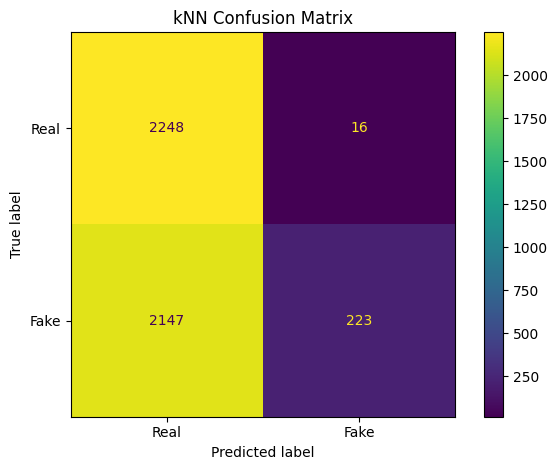


Logistic Regression
Accuracy: 0.7658610271903323
Precision: 0.8344612181155648
Recall: 0.6763713080168776
F1-score: 0.7471451876019576
Confusion Matrix:
[[1946  318]
 [ 767 1603]]


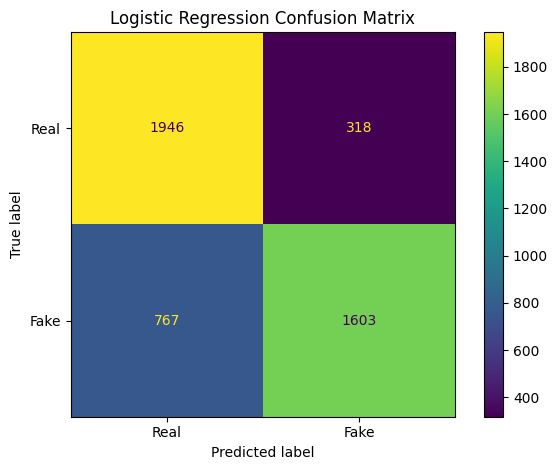


Naive Bayes
Accuracy: 0.7002589555459646
Precision: 0.6864310148232611
Recall: 0.7620253164556962
F1-score: 0.7222555488902219
Confusion Matrix:
[[1439  825]
 [ 564 1806]]


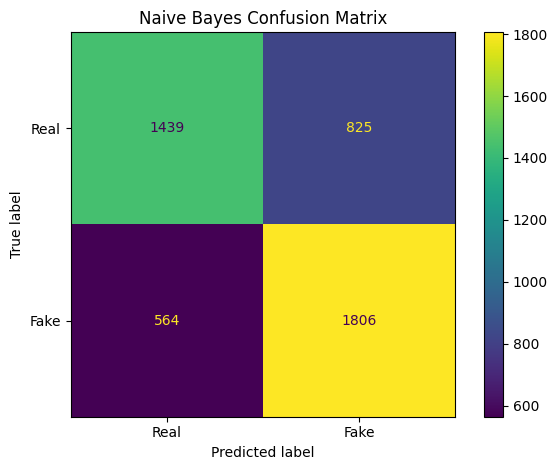


MLP Neural Network
Accuracy: 0.7175226586102719
Precision: 0.9723953695458593
Recall: 0.4607594936708861
F1-score: 0.625250501002004
Confusion Matrix:
[[2233   31]
 [1278 1092]]


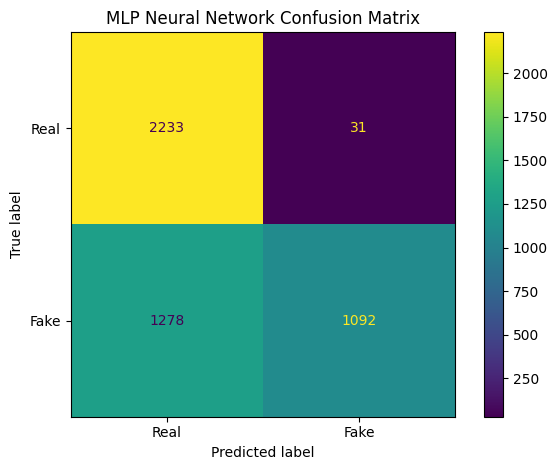

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
  """
    Train machine learning models and evaluate its performance.

    evaluate_model() is trained on the training dataset and evaluated on the
    testing dataset using accuracy, precision, recall, and F1-score.
    A confusion matrix is also displayed to visualize classification
    performance.

    param:
    name : str
        Name of the model being evaluated.
    model : sklearn
        Machine learning model to train and test.
    X_train : numpy.ndarray
        Training feature matrix.
    X_test : numpy.ndarray
        Testing feature matrix.
    y_train : numpy.ndarray
        Training labels.
    y_test : numpy.ndarray
        Testing labels.

    return:
    tuple
        Accuracy, precision, recall, and F1-score.
    """

    model.fit(X_train, y_train)
    # generate predictions for the testing data
    pred = model.predict(X_test)

    # compute classification performance metrics
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    # display evaluation results
    print("\n" + name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

    # create and display confusion matrix
    cm = confusion_matrix(y_test, pred)
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Real", "Fake"]
    )

    display.plot()
    plt.title(name + " Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return accuracy, precision, recall, f1

# ML models used for comparison
models = {
    "kNN": KNeighborsClassifier(n_neighbors=5),

    "Logistic Regression": LogisticRegression(max_iter=3000),

    "Naive Bayes": GaussianNB(),

    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )
}

results = {} # store evaluation results for each model

# train and evaluate each model(knn, logistic reg., etc)
for name, model in models.items():
    accuracy, precision, recall, f1 = evaluate_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

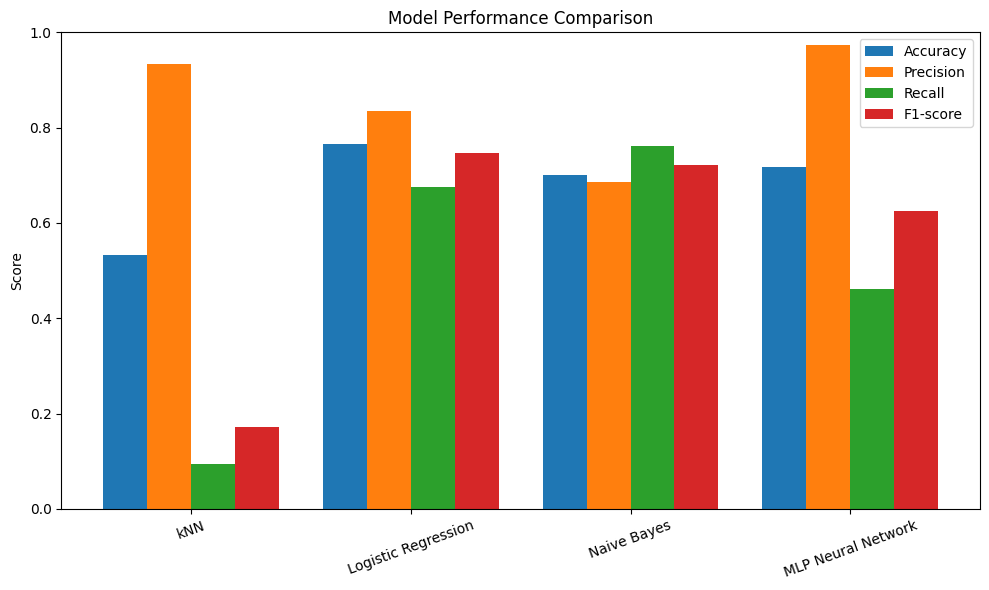


Total runtime: 50.01 minutes


In [ ]:
# extract performance metrics for each model
model_names = list(results.keys())

accuracies = [results[name]["accuracy"] for name in model_names]
precisions = [results[name]["precision"] for name in model_names]
recalls = [results[name]["recall"] for name in model_names]
f1_scores = [results[name]["f1"] for name in model_names]

x = np.arange(len(model_names))
width = 0.2

# generate bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, accuracies, width, label="Accuracy")
plt.bar(x - 0.5 * width, precisions, width, label="Precision")
plt.bar(x + 0.5 * width, recalls, width, label="Recall")
plt.bar(x + 1.5 * width, f1_scores, width, label="F1-score")

plt.xticks(x, model_names, rotation=20)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# display total runtime
print(f"\nTotal runtime: {(time.time() - start) / 60:.2f} minutes")